In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [23]:
load_dotenv()  # Load environment variables from .env file
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [24]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [25]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [26]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [27]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()# Initialize the InMemorySaver checkpoint to store the state of the graph in memory

workflow = graph.compile(checkpointer=checkpointer)


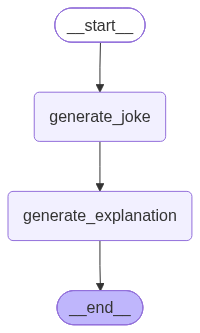

In [28]:
workflow

In [29]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with *dough*‑mestic experience and a *crust*‑worthy work ethic! 🍕😄',
 'explanation': '**Explanation of the joke**\n\n> **Why did the pizza apply for a job?**  \n> **Because it heard the company was looking for someone with *dough‑mestic* experience and a *crust‑worthy* work ethic! 🍕😄**\n\n---\n\n### 1. The set‑up  \nThe question “Why did the pizza apply for a job?” already hints that the punchline will involve a play on words related to pizza. It makes us picture a slice of pizza behaving like a person looking for employment.\n\n### 2. The punchline – two puns in one\n\n| Phrase in the punchline | What it sounds like / means normally | How it’s twisted to refer to pizza |\n|--------------------------|--------------------------------------|------------------------------------|\n| **dough‑mestic experience** | “Domestic experience” = experience working at home or in a h

In [30]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with *dough*‑mestic experience and a *crust*‑worthy work ethic! 🍕😄', 'explanation': '**Explanation of the joke**\n\n> **Why did the pizza apply for a job?**  \n> **Because it heard the company was looking for someone with *dough‑mestic* experience and a *crust‑worthy* work ethic! 🍕😄**\n\n---\n\n### 1. The set‑up  \nThe question “Why did the pizza apply for a job?” already hints that the punchline will involve a play on words related to pizza. It makes us picture a slice of pizza behaving like a person looking for employment.\n\n### 2. The punchline – two puns in one\n\n| Phrase in the punchline | What it sounds like / means normally | How it’s twisted to refer to pizza |\n|--------------------------|--------------------------------------|------------------------------------|\n| **dough‑mestic experience** | “Domestic experience” = experience workin

In [31]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with *dough*‑mestic experience and a *crust*‑worthy work ethic! 🍕😄', 'explanation': '**Explanation of the joke**\n\n> **Why did the pizza apply for a job?**  \n> **Because it heard the company was looking for someone with *dough‑mestic* experience and a *crust‑worthy* work ethic! 🍕😄**\n\n---\n\n### 1. The set‑up  \nThe question “Why did the pizza apply for a job?” already hints that the punchline will involve a play on words related to pizza. It makes us picture a slice of pizza behaving like a person looking for employment.\n\n### 2. The punchline – two puns in one\n\n| Phrase in the punchline | What it sounds like / means normally | How it’s twisted to refer to pizza |\n|--------------------------|--------------------------------------|------------------------------------|\n| **dough‑mestic experience** | “Domestic experience” = experience worki

In [32]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it *pasta*ble to *ketchup* with the competition and always *rolled* out the best ideas! 🍝😄',
 'explanation': '**What makes the joke funny?**  \nThe humor comes from a series of puns that replace ordinary words with food‑related words that sound similar. Because the subject of the joke is *spaghetti*—a type of pasta—the punchline can play with the language of cooking while still sounding like a normal business‑world compliment. Let’s break it down piece by piece.\n\n| Phrase in the punchline | What it sounds like / usual meaning | The food‑related twist | Why it works |\n|--------------------------|--------------------------------------|------------------------|--------------|\n| **“pasta‑ble”** | *possible* – meaning “able to be done” | *pasta* (the category of food that includes spaghetti) + the suffix “‑able” | The word *possible* is replaced by *pasta‑ble*, turning a plain adjective into a noodle‑themed o

In [33]:
workflow.get_state(config =config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it *pasta*ble to *ketchup* with the competition and always *rolled* out the best ideas! 🍝😄', 'explanation': '**What makes the joke funny?**  \nThe humor comes from a series of puns that replace ordinary words with food‑related words that sound similar. Because the subject of the joke is *spaghetti*—a type of pasta—the punchline can play with the language of cooking while still sounding like a normal business‑world compliment. Let’s break it down piece by piece.\n\n| Phrase in the punchline | What it sounds like / usual meaning | The food‑related twist | Why it works |\n|--------------------------|--------------------------------------|------------------------|--------------|\n| **“pasta‑ble”** | *possible* – meaning “able to be done” | *pasta* (the category of food that includes spaghetti) + the suffix “‑able” | The word *possible* is replaced by *pasta‑ble*, turning a plain adjective int

In [34]:
list(workflow.get_state_history(config2))
#here first printed start node then generate joke .....
#here we use list wrapper because workflow.get_state_history(config2) returns an iterator 
#  so that we can see all the states in the history for the given config.

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it *pasta*ble to *ketchup* with the competition and always *rolled* out the best ideas! 🍝😄', 'explanation': '**What makes the joke funny?**  \nThe humor comes from a series of puns that replace ordinary words with food‑related words that sound similar. Because the subject of the joke is *spaghetti*—a type of pasta—the punchline can play with the language of cooking while still sounding like a normal business‑world compliment. Let’s break it down piece by piece.\n\n| Phrase in the punchline | What it sounds like / usual meaning | The food‑related twist | Why it works |\n|--------------------------|--------------------------------------|------------------------|--------------|\n| **“pasta‑ble”** | *possible* – meaning “able to be done” | *pasta* (the category of food that includes spaghetti) + the suffix “‑able” | The word *possible* is replaced by *pasta‑ble*, turning a plain adjective in

## time travel we can start from any checkpoint by id 

In [41]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1c41db-9c8e-6565-8000-c327f33cf929"}})
# here we ahve extra passed checkpoint_id in the config to get the state of the graph at that particular checkpoint for the given thread_id.

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1c41db-9c8e-6565-8000-c327f33cf929'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [43]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1c41db-9c8e-6565-8000-c327f33cf929"}})

# here i have not provided an initial state to the workflow.invoke method because we are resuming the workflow from a specific checkpoint,
#  so the state will be retrieved from that checkpoint instead of being initialized from scratch.

EmptyInputError: Received no input for __start__